## Leveraging Discrete Distributional Derivatives to Assess Strike Prices via Jump Detection Techniques

### Kenneth A. Anderson, Howard University

$\textbf{Introduction:}$ Goal is to connect functional analysis techniques with options trading
* Distributional derivatives are generalizations of classical derivatives, but are well-known for their ability to detect abnormal jumps in functions
* Implied Volatility (IV) is a key component in options pricing, but may exhibit unexpected jumps
* Large jumps may indicate that a market-maker has made a mistake or perhaps the strike is mispriced or misorderd
* In this exercise, I chose Caterpillar (CAT) a well-known Mega-Cap stock that has high IV (data included valid contracts that were about a month out from expiration)
* Options with high volatility may present opportunties, but also may incur higher transaction costs, so any additional competitive advantages for assessing strike prices could be useful


$\textbf{Strategy:}$ Leverage the discrete analog of distributional derivatives to assess changes in implied volatility relative to strike prices and affirm fair strike prices or detect mispriced/misordered call prices.

* Given that high IV may exhibit sudden jumps, these jumps could be captured systematically to inform options trading strategies, particularly with selecting strike prices to inform hedging strategies
* Typically, in options trading, when comparing available contracts, implied volatility should be fairly smooth and should not exhibit sudden jumps from one strike price to the next.

$\textbf{Jump Detector}:$ Leverages second-order finite-differences of IV between neighboring strike prices to detect jumps (normal or abnormal) using the following approach:
  $$ \Delta^2IV = IV_{i+1} - 2IV_i +IV_{i-1}  \approx \frac{d^2}{dS^2}IV(S) $$

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
import matplotlib.pyplot as plt


## Step 1. Load and Clean Data

In [3]:
df = pd.read_csv("options_data.csv")
df = df.dropna(subset=["Strike", "IV"])       
df = df.sort_values("Strike")

S = df["Strike"].values.astype(float)
iv = df["IV"].values.astype(float)

## Step 2. Define Function to Create a Smooth IV Curve (Median Filter)

In [4]:
def smooth_iv(iv, kernel=5):
    """Apply a median filter with safe kernel size."""
    kernel = max(3, min(kernel, len(iv) - (1 - len(iv) % 2)))
    return medfilt(iv, kernel_size=kernel)

iv_smooth = smooth_iv(iv, kernel=5)

## Step 3. Compute Second-Order Discrete Derivative (Distributional)

In [5]:
def second_derivative(iv):
    """Return the discrete second derivative array."""
    sec = np.zeros_like(iv)
    for i in range(1, len(iv) - 1):
        sec[i] = iv[i+1] - 2*iv[i] + iv[i-1]
    return sec

iv_dd = second_derivative(iv)

## Step 4. Define the Jump Detector using Customizable Thresholds

In [6]:
def detect_jumps(S, iv_dd, threshold=0.005, min_sep=2):
    """
    Detect IV jumps using second derivative curvature.
    threshold: minimum magnitude of curvature to count as jump.
    min_sep: minimum index separation between jumps.
    """
    jumps = []
    last_idx = -min_sep
    
    for i in range(1, len(iv_dd) - 1):
        if abs(iv_dd[i]) > threshold and (i - last_idx) >= min_sep:
            jumps.append((i, float(S[i]), float(iv_dd[i])))
            last_idx = i
    return jumps

jumps = detect_jumps(S, iv_dd, threshold=0.005)

## Step 5. Plot IV, Smooth IV, and Jumps for Visual Inspection

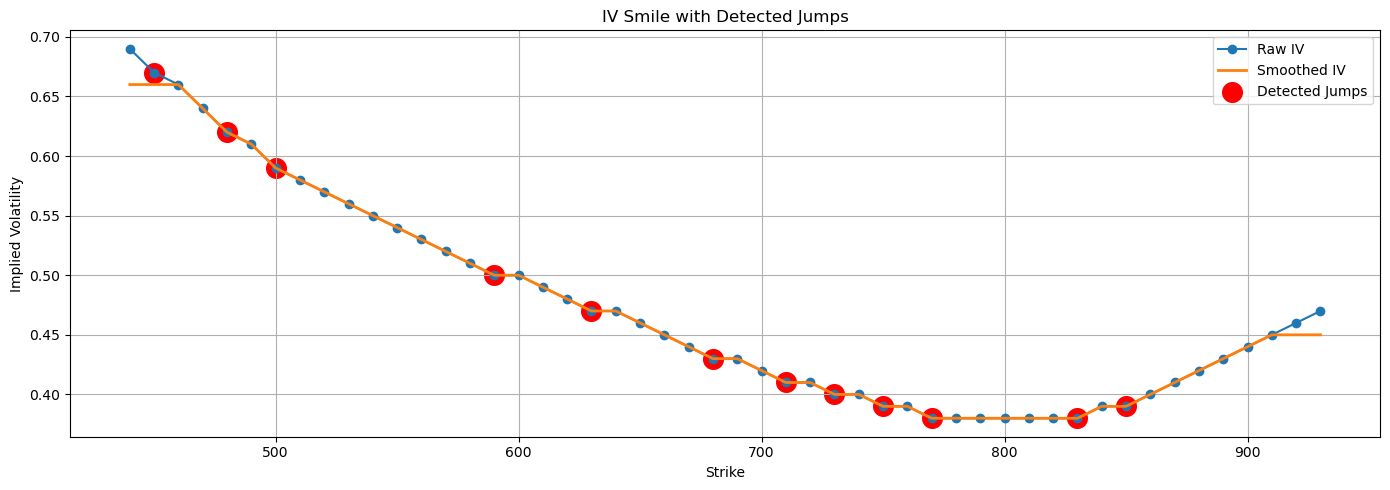

In [18]:
plt.figure(figsize=(14,5))
plt.plot(S, iv, label="Raw IV", marker="o")
plt.plot(S, iv_smooth, label="Smoothed IV", linewidth=2)

if jumps:
    idx = [j[0] for j in jumps]
    plt.scatter(S[idx], iv[idx], color="red", s=200, label="Detected Jumps")

plt.title("IV Smile with Detected Jumps")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("iv_jumps_clean.png")
plt.show()

## Step 6. Print Jump Table to Review Questionable Strikes

In [8]:
print("\nDetected IV Jumps:")
print("Index | Strike | Δ²IV")
print("-"*30)
for idx, strike, curv in jumps:
    print(f"{idx:5d} | {strike:6.1f} | {curv:+.5f}")


Detected IV Jumps:
Index | Strike | Δ²IV
------------------------------
    1 |  450.0 | +0.01000
    4 |  480.0 | +0.01000
    6 |  500.0 | +0.01000
   15 |  590.0 | +0.01000
   19 |  630.0 | +0.01000
   24 |  680.0 | +0.01000
   27 |  710.0 | +0.01000
   29 |  730.0 | +0.01000
   31 |  750.0 | +0.01000
   33 |  770.0 | +0.01000
   39 |  830.0 | +0.01000
   41 |  850.0 | +0.01000


## Reflections / Next Steps

* The Jump Detector provides an additional quality assurance measure
* The clean six-step procedure does not reflect the "graveyard" code
* There were a lot of iterations to find anomolies in strike prices. The data were obtained from Webull, a reputable company, so it was difficult to detect any abnormal jumps
* The procedure does affirm the normal, non-smooth behavior of implied volatility relative to strike prices, but no major anomalies were detected.
* This Jump Detector may be more useful with small-market cap stocks where implied volatility may be more uneven
* This six-step procedure focuses on cross-sectional strikes for a single day, but additional Jump Detectors that assess implied volatility over time may be useful in the future